# **Catalogue Simulations for the WISEMAN simulator**

- **WISEMAN** \[1\] is a physics-based Monte Carlo C++ simulator built to assess the performace of the **Wide Field Monitor** (WFM) instrument, originally designed and developed for the LOFT, STROBE-X, eXTP and LEM-X \[2, 3\] space missions.

- This software provides a realistic photon-by-photon Monte Carlo simulation from the astrophysical sources down to the scientific data at the instrument level for a single WFM coded-mask camera. Each photon is generated at a given instant from a given sky direction and with a given energy, transported through a coded-mask camera, detected, and processed by the on-board front-end and back-end electronics.

- This notebook exploits the `wmsims` mini-package to simulate a given number of sources in a sky-field, with the possibility to specify custom PDFs for the sources coordinates and flux values distributions. The initialised sources are then stored into a database and saved as a `CSV` file.

**Libraries**

In [1]:
from typing import Callable

import numpy as np
from numpy.typing import NDArray
from pandas import DataFrame

from bloodmoon.mask import CodedMaskCamera
import darksun as ds
from darksun.data import Log

import wmsims as wm
from wmsims.fields import CameraPointer, Coords, Source

In [2]:
# plotting setup
import matplotlib.pyplot as plt
plt.style.use('dark_background')
plt.ioff()

**Coded-mask cameras mask design and pointings setup**

In [3]:
base_path: str = "/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations"
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

wfm: CodedMaskCamera = wm.init_cameras_mask(f"{base_path}/{MASK_FITS}")
sdl: CameraPointer = wm.define_unit_pointings(
    z_axis_RA=266.4,
    z_axis_DEC=-28.94,
    x_axis_RA=266.4,
    x_axis_DEC=61.06,
)

**Catalogue setup**

In [4]:
n_sources: int = 40
fov: tuple[float, float] = (-40.0, 40.0)   # [deg]
f_min: float = 4.0e-2                      # [Crab]
f_max: float = 10.0                        # [Crab]

**Simulate sources**

In [5]:
# custom PDF kernel for sources flux distribution
from scipy.special import gamma

def mod_kernel(
    x: NDArray,
    alpha: float,
    k: float,
    beta: float,
) -> NDArray:
    """Custom exp - power law probability distribution function."""
    f = (alpha + 1) / beta
    a = beta * np.pow(k, f) / gamma(f)
    t = - k * np.pow(x, beta)
    return np.abs(a * np.pow(x, alpha) * np.exp(t))

In [ ]:
# simul sources camera local-frame angular sources
coords: tuple[Coords, ...] = wm.simul_coords(
    n_sources=n_sources,
    fov_along_x=fov,
    fov_along_y=fov,
)

# simul sources fluxes
factors = (2.0, 4.0, 2.0)
flux_pdf: Callable[[NDArray], NDArray] = wm.config_pdf(mod_kernel, *factors)

fluxes: tuple[float, ...] = wm.simul_fluxes(
    n_sources=n_sources,
    f_min=f_min,
    f_max=f_max,
    pdf=flux_pdf,
)
print(f"Total flux from sources: {sum(fluxes):.3f} Crab")

# get sources
sources: tuple[Source, ...] = wm.get_sources(coords, fluxes)

In [ ]:
import random

def handmade_fluxes(
    n_sources: tuple[int, ...],
    flux_lims: tuple[tuple[float, float], ...],
    shuffle: bool = True,
) -> tuple[float, ...]:
    """
    Custom handmade sources flux simul from uniform PDF.
    Flux limits must be inserted in [Crab] unit.
    """
    # adjust inputs for lazy people (like me, lol)
    n_sources_ = (n_sources,) if isinstance(n_sources, int) else n_sources
    flux_lims_ = (flux_lims,) if not isinstance(flux_lims[0], tuple) else flux_lims

    if not len(n_sources_) == len(flux_lims_):
        raise ValueError("Input 'n_sources' and 'flux_lims' must have same length.")
    
    fluxes: list = []
    for idx, n in enumerate(n_sources_):
        fluxes += list(wm.simul_fluxes(n, *flux_lims_[idx]))
    
    if shuffle: random.shuffle(fluxes)
    
    return tuple(fluxes)


handmade_fluxes(
    n_sources=2,
    flux_lims=(2, 3),
)

(np.float64(2.0661), np.float64(2.56))

**Catalogue generation and visualisation**

In [7]:
SAVE_THINGS: bool = False

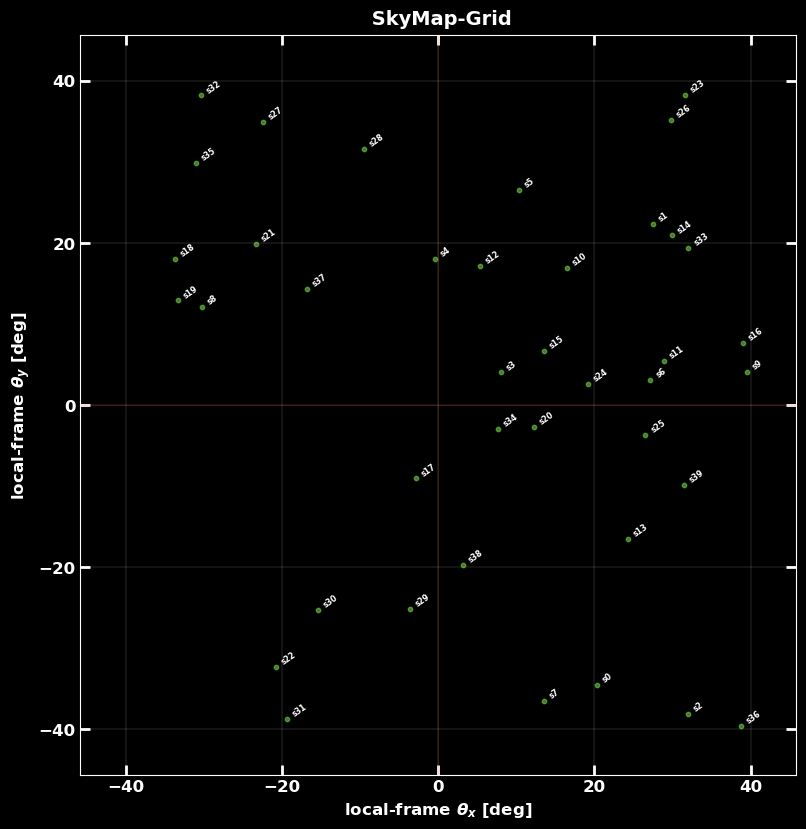

In [8]:
# gen Log structure for sources and show sky-field
log: Log = wm.gen_data_log(sources)

SAVE_TO: str = '/home/edoardo/Desktop'
#SAVE_TO: str = '/mnt/d/PhD_AASS/Coding/Images_fits'
ds.skyfield_map(
    log=log,
    camera=wfm,
    show_IDs=True,
    save_to=(
        ds.savefig_to(SAVE_TO, 'skymap', overwrite=True)
        if SAVE_THINGS else None
    ),
)

In [9]:
# - Gen catalogue dataframe
df: DataFrame = wm.make_catalog(
    sources=sources,
    sdl=sdl,
    camera=wfm,
    save_to=(
        f'{SAVE_TO}/catalogue.csv' if SAVE_THINGS else None
    ),
)

<br>
<br>

### **References**

**\[1\]** Ceraudo, F. et al. Development of the end-to-end simulator of the WFM camera, Vol. 13093 of Society of Photo-Optical Instrumentation Engineers (SPIE) Conference Series, 130936T (2024)

**\[2\]** Del Monte, E. et al., Status of the Lunar Electromagnetic Monitor in X-rays (LEM-X), in [Space Telescopes and Instrumentation 2024: Ultraviolet to Gamma Ray], den Herder, J.-W. A., Nikzad, S., and Nakazawa, K., eds., Society of Photo-Optical Instrumentation Engineers (SPIE) Conference Series 13093, this proceedings (2024)

**\[3\]** Del Monte, E. et al., The Lunar Electromagnetic Monitor in X-rays (LEM-X), _in preparation_, (2025)